# Gaussian Belief Propagation for the Diffusion Score — companion notebook

This notebook reproduces the **main results and experiments** of `main.pdf` for the
Gaussian AR(1) + Ornstein–Uhlenbeck model. Everything is closed form; nothing uses
neural networks. The companion code lives in `code/` and is the same audited code
that backs the paper.

**Map**
1. Model & the noisy law $P_t(x)=\mathcal N(0,\Sigma_t)$
2. The score two ways: $-\Sigma_t^{-1}x$ vs. Tweedie denoiser — they agree
3. Belief propagation on the $K=3$ chain: the numeric message tables
4. BP reconstructs the exact score (precision matrix) at machine precision
5. **BP vs AMP**: same score, different variance (and AMP breakdown on the chain)
6. **Experiment A**: local messages vs full sweeps
7. **Experiment B**: lifecycle of the precision matrix $\Sigma_t^{-1}$
8. The full numerical audit (59/59 checks)


In [1]:
import sys, os
sys.path.insert(0, 'code')
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from ar1_utils import (ar1_covariance, ar1_precision_clean, ou_params, sigma_t,
                       precision_t, joint_score_matrix, joint_score_via_tweedie,
                       gaussian_posterior)
from bp_score import bp_posterior, bp_score, _forward_pass, _backward_pass, _evidence_in_a, _gaussian_product
from amp import (posterior_precision_field, exact_marginals, mean_iteration,
                 amp_variance, mean_field_variance, amp_score)
from local_bp import local_score
np.set_printoptions(precision=4, suppress=True)
print('modules loaded')

modules loaded


## 1. Model and the noisy law

Stationary AR(1): $a_{k+1}=\alpha a_k+\eta_k$, $\eta_k\sim\mathcal N(0,1-\alpha^2)$, so
$\mathrm{Var}(a_k)=1$. Clean covariance $\Sigma_0[i,j]=\alpha^{|i-j|}$; its inverse
$Q_0=\Sigma_0^{-1}$ is **tridiagonal** (Markov). After OU diffusion,
$\Sigma_t=e^{-2t}\Sigma_0+\Delta_t I$ with $\Delta_t=1-e^{-2t}$.

In [2]:
K, alpha, t = 6, 0.8, 0.4
Sigma_0 = ar1_covariance(K, alpha)
Q0 = ar1_precision_clean(K, alpha)
print('Sigma_0 (dense Toeplitz):\n', Sigma_0)
print('\nQ0 = Sigma_0^-1 (tridiagonal):\n', Q0)
print('\nmax |Q0 - inv(Sigma_0)| =', np.max(np.abs(Q0 - np.linalg.inv(Sigma_0))))
print('off-tridiagonal mass of Q0 =', np.max(np.abs(Q0 - np.triu(np.tril(Q0,1),-1))))

Sigma_0 (dense Toeplitz):
 [[1.     0.8    0.64   0.512  0.4096 0.3277]
 [0.8    1.     0.8    0.64   0.512  0.4096]
 [0.64   0.8    1.     0.8    0.64   0.512 ]
 [0.512  0.64   0.8    1.     0.8    0.64  ]
 [0.4096 0.512  0.64   0.8    1.     0.8   ]
 [0.3277 0.4096 0.512  0.64   0.8    1.    ]]

Q0 = Sigma_0^-1 (tridiagonal):
 [[ 2.7778 -2.2222  0.      0.      0.      0.    ]
 [-2.2222  4.5556 -2.2222  0.      0.      0.    ]
 [ 0.     -2.2222  4.5556 -2.2222  0.      0.    ]
 [ 0.      0.     -2.2222  4.5556 -2.2222  0.    ]
 [ 0.      0.      0.     -2.2222  4.5556 -2.2222]
 [ 0.      0.      0.      0.     -2.2222  2.7778]]

max |Q0 - inv(Sigma_0)| = 1.7763568394002505e-15
off-tridiagonal mass of Q0 = 0.0


## 2. The score two ways

Direct: $S(x,t)=-\Sigma_t^{-1}x$. Bayesian (Tweedie):
$S_k=(e^{-t}\langle a_k\rangle_{a|x}-x_k)/\Delta_t$. They are the same vector.

In [3]:
rng = np.random.default_rng(0)
x = rng.standard_normal(K)
S_matrix  = joint_score_matrix(x, t, Sigma_0, alpha)
S_tweedie = joint_score_via_tweedie(x, t, Sigma_0, alpha)
print('S (matrix) =', S_matrix)
print('S (Tweedie)=', S_tweedie)
print('max abs diff =', np.max(np.abs(S_matrix - S_tweedie)))

S (matrix) = [-0.0897  0.3803 -0.8742 -0.0599  0.9297 -0.5342]
S (Tweedie)= [-0.0897  0.3803 -0.8742 -0.0599  0.9297 -0.5342]
max abs diff = 2.220446049250313e-16


## 3. Belief propagation on the $K=3$ chain — message tables

We run the forward (Kalman filter) and backward (RTS smoother) sweeps and print the
numeric $(\text{mean},\text{variance})$ of every message, then recombine at each node
and compare with the exact matrix posterior. Convention A: local evidence is inserted
at combination time, never inside a recursion (this avoids double-counting $x_k$).

In [4]:
K3, alpha3, t3 = 3, 0.7, 0.5
x3 = np.array([1.2, -0.4, 0.8])
sig_eta = np.sqrt(1 - alpha3**2)
mu_, Delta_ = ou_params(t3)

m_to, v_to = _forward_pass(x3, t3, alpha3, sig_eta, 0.0, 1.0)
m_lr, v_lr = _backward_pass(x3, t3, alpha3, sig_eta)

print('Forward messages  mu_->k(a_k)   (carry x_0..x_{k-1}):')
for k in range(K3):
    print(f'  k={k}:  mean={m_to[k]:+.4f}  var={v_to[k]:.4f}')
print('\nBackward messages mu_<-k(a_k)   (carry x_{k+1}..x_{K-1}):')
for k in range(K3):
    vv = 'inf' if np.isinf(v_lr[k]) else f'{v_lr[k]:.4f}'
    print(f'  k={k}:  mean={m_lr[k]:+.4f}  var={vv}')

print('\nCombine forward * evidence * backward at each node:')
for k in range(K3):
    m_ev, v_ev = _evidence_in_a(x3[k], t3)
    m_a, v_a = _gaussian_product(m_to[k], v_to[k], m_ev, v_ev)
    m_b, v_b = _gaussian_product(m_a, v_a, m_lr[k], v_lr[k])
    print(f'  posterior a_{k}:  mean={m_b:+.4f}  var={v_b:.4f}')

mu_post, Sig_post = gaussian_posterior(x3, t3, ar1_covariance(K3, alpha3), alpha3)
print('\nExact matrix posterior mean      =', mu_post)
print('Exact matrix posterior variances =', np.diag(Sig_post))

Forward messages  mu_->k(a_k)   (carry x_0..x_{k-1}):
  k=0:  mean=+0.0000  var=1.0000
  k=1:  mean=+0.5095  var=0.8197
  k=2:  mean=+0.0923  var=0.7819

Backward messages mu_<-k(a_k)   (carry x_{k+1}..x_{K-1}):
  k=0:  mean=+0.0544  var=3.5859
  k=1:  mean=+1.8843  var=4.5475
  k=2:  mean=+0.0000  var=inf

Combine forward * evidence * backward at each node:
  posterior a_0:  mean=+0.6269  var=0.5374
  posterior a_1:  mean=+0.3225  var=0.4946
  posterior a_2:  mean=+0.4760  var=0.5374

Exact matrix posterior mean      = [0.6269 0.3225 0.476 ]
Exact matrix posterior variances = [0.5374 0.4946 0.5374]


## 4. BP reconstructs the exact score through the precision matrix

Across many $(K,\alpha,t)$ the BP score equals $-\Sigma_t^{-1}x$ to machine precision.

In [5]:
err = 0.0
for Kk in (2,3,5,8,16):
    for aa in (0.2,0.5,0.9,-0.4):
        for tt in (0.05,0.3,1.0,3.0):
            xx = np.random.default_rng(Kk).standard_normal(Kk)
            err = max(err, np.max(np.abs(bp_score(xx,tt,aa)
                       - joint_score_matrix(xx,tt,ar1_covariance(Kk,aa),aa))))
print('max |S_BP - S_exact| over 80 configs =', err)

max |S_BP - S_exact| over 80 configs = 1.4210854715202004e-14


## 5. BP vs AMP — same score, different variance

For a Gaussian model the posterior **mean** solves $Jm=h$, so mean-field, BP and AMP
share the exact mean → **the same score**. They differ only in the **variance** closure.
AMP's `V_i = 1/(J_ii - Σ_k J_ik² V_k)` is exact on a dense graph but, on the degree-2
chain, accurate only at weak coupling and with **no physical fixed point** at strong
coupling. BP stays exact.

chain K=9, alpha=0.8:  mean error (AMP vs exact) and AMP variance status
  t=0.05 |m_amp-m_exact|=1.2e-13   AMP var err: 1.30e-04
  t=0.2  |m_amp-m_exact|=4.6e-13   AMP var err: 3.48e-02
  t=0.5  |m_amp-m_exact|=1.1e-12   AMP var err: breakdown (no fixed point)
  t=1.0  |m_amp-m_exact|=2.4e-12   AMP var err: breakdown (no fixed point)
  t=2.0  |m_amp-m_exact|=3.9e-12   AMP var err: breakdown (no fixed point)

(figure below: means coincide for all t; variance fails)


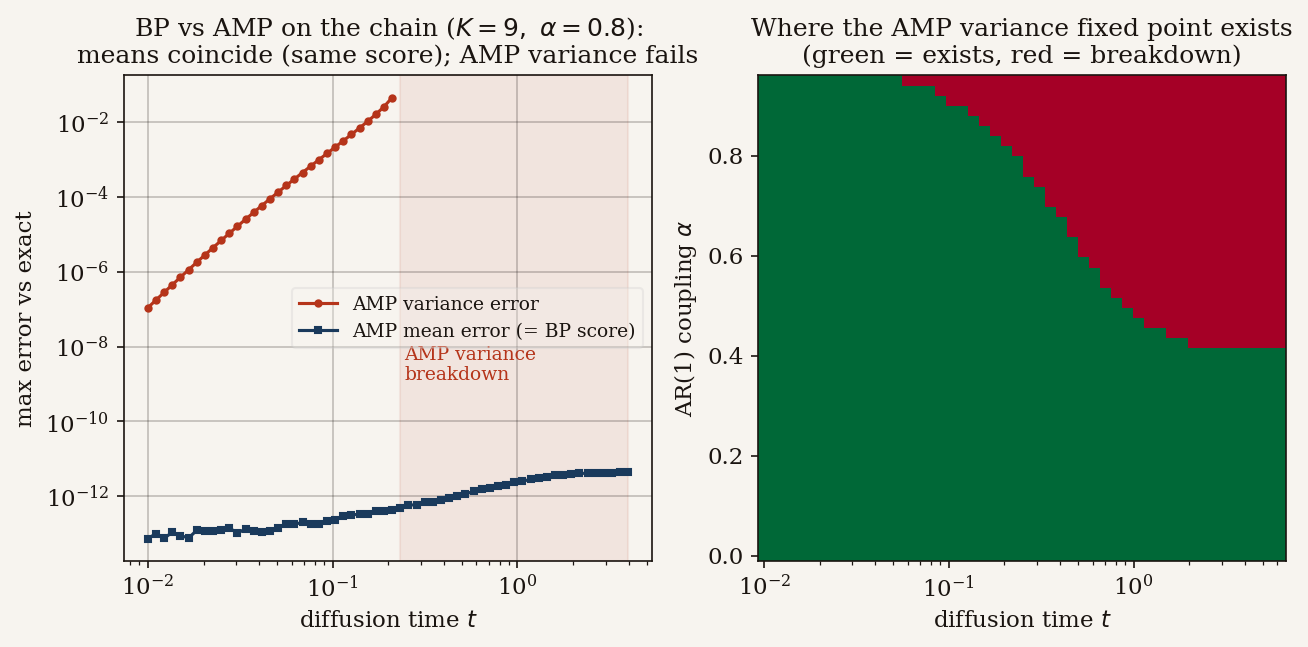

In [6]:
Kc, ac = 9, 0.8
xc = np.random.default_rng(21).standard_normal(Kc)
print(f'chain K={Kc}, alpha={ac}:  mean error (AMP vs exact) and AMP variance status')
for tt in (0.05, 0.2, 0.5, 1.0, 2.0):
    J,h = posterior_precision_field(xc, tt, ac)
    m_ex, v_ex = exact_marginals(J,h)
    m_amp = mean_iteration(J,h)[0]
    v_amp, _, ok = amp_variance(J)
    vtxt = f'{np.max(np.abs(v_amp-v_ex)):.2e}' if ok else 'breakdown (no fixed point)'
    print(f'  t={tt:<4} |m_amp-m_exact|={np.max(np.abs(m_amp-m_ex)):.1e}   AMP var err: {vtxt}')
print('\n(figure below: means coincide for all t; variance fails)')
display(Image(filename='figures/fig_bp_vs_amp.png'))

## 6. Experiment A — local messages vs full sweeps

Local radius-$r$ estimator uses only observations within distance $r$. $r=K-1$ is full
BP (exact). The locality error decays geometrically with $r$ and is largest at
intermediate $t$.

t=0.1:  r=0:5.6e+00  r=1:1.1e+00  r=2:2.2e-01  r=4:1.6e-02  r=8:9.1e-05  r=20:5.6e-15
t=0.5:  r=0:1.2e+00  r=1:5.6e-01  r=2:2.7e-01  r=4:8.8e-02  r=8:1.2e-02  r=20:8.9e-16
t=2.0:  r=0:5.5e-02  r=1:4.7e-02  r=2:3.7e-02  r=4:1.4e-02  r=8:6.0e-03  r=20:4.4e-16


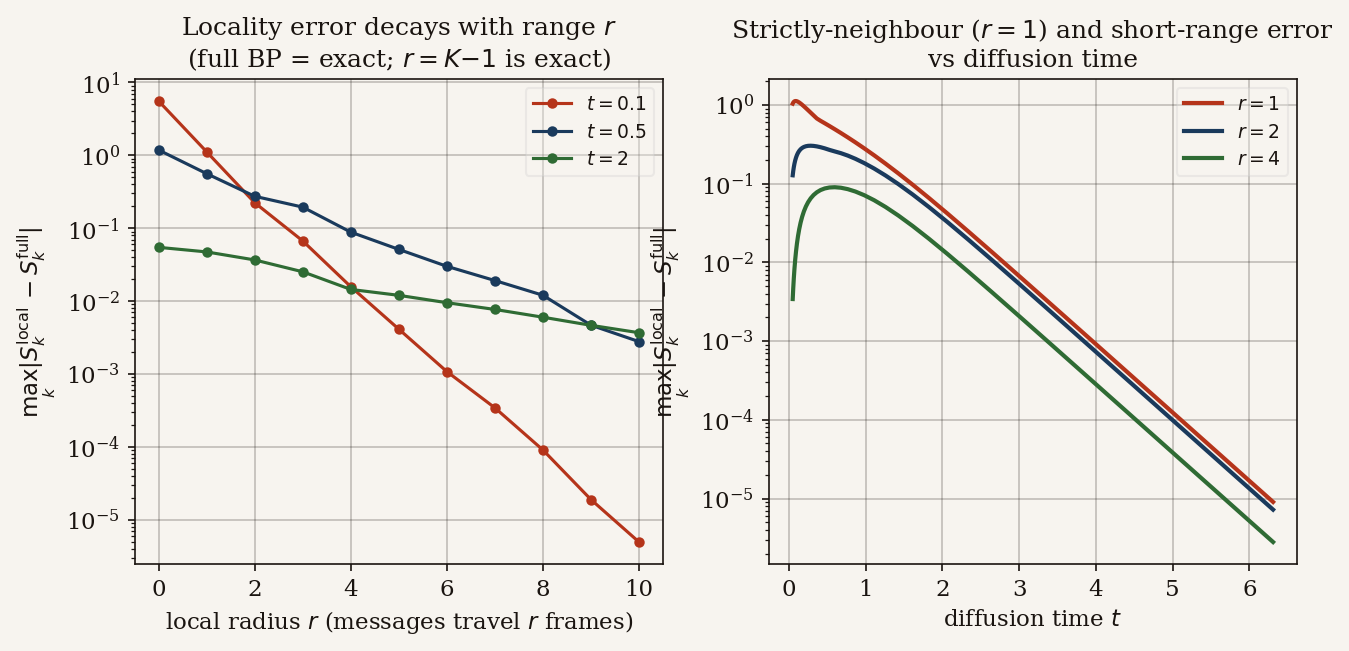

In [7]:
KA, aA = 21, 0.8
xA = np.random.default_rng(3).standard_normal(KA)
Sig0A = ar1_covariance(KA, aA)
for tt in (0.1, 0.5, 2.0):
    s_full = joint_score_matrix(xA, tt, Sig0A, aA)
    print(f't={tt}:  ' + '  '.join(
        f'r={r}:{np.max(np.abs(local_score(xA,tt,aA,r)-s_full)):.1e}'
        for r in (0,1,2,4,8,KA-1)))
display(Image(filename='figures/fig_local_vs_full.png'))

## 7. Experiment B — lifecycle of the precision matrix

$Q_t=\Sigma_t^{-1}$ is tridiagonal at $t=0$, the band fills for $t>0$, and $Q_t\to I$ as
$t\to\infty$. Eigenvectors are shared with $\Sigma_0$ (near-Fourier); the band fill obeys
$|Q_t[i,i+d]|\sim(2t)^{d-1}$ (no $1/(d-1)!$ factor).

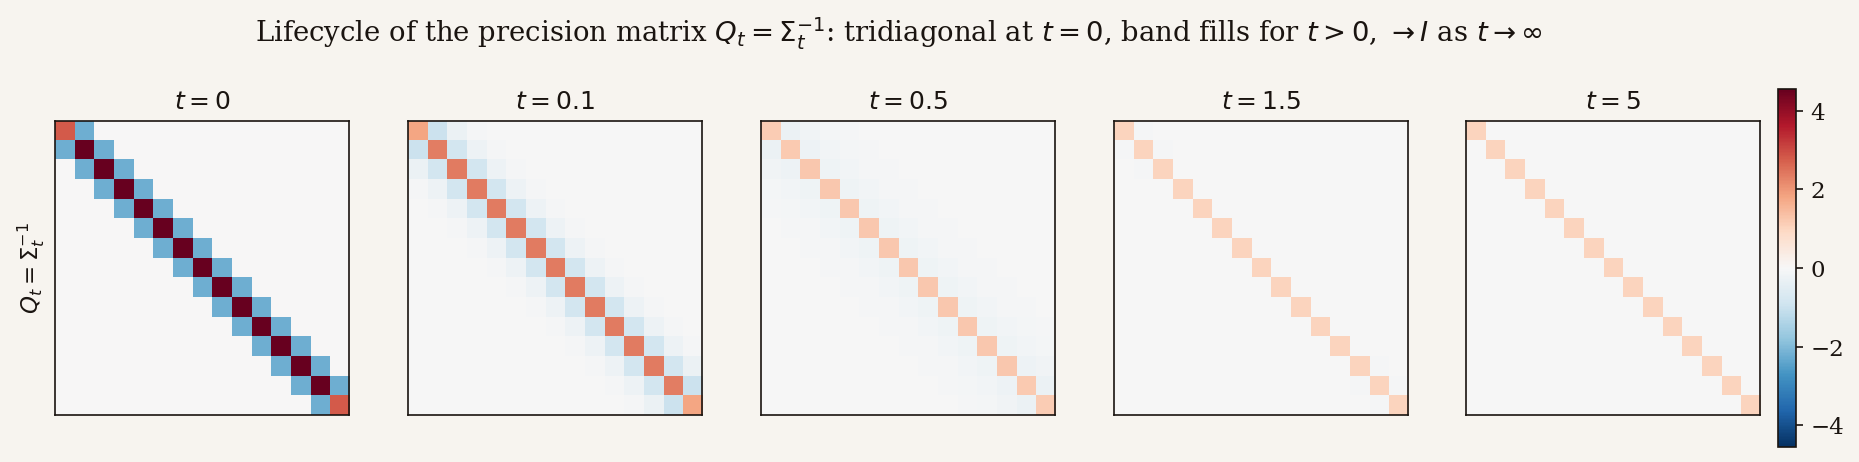

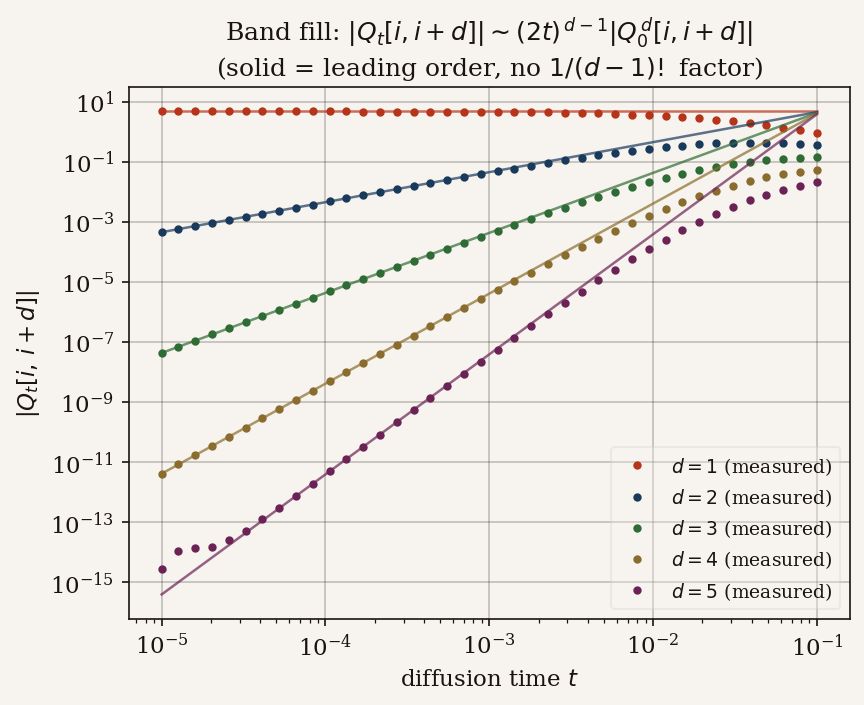

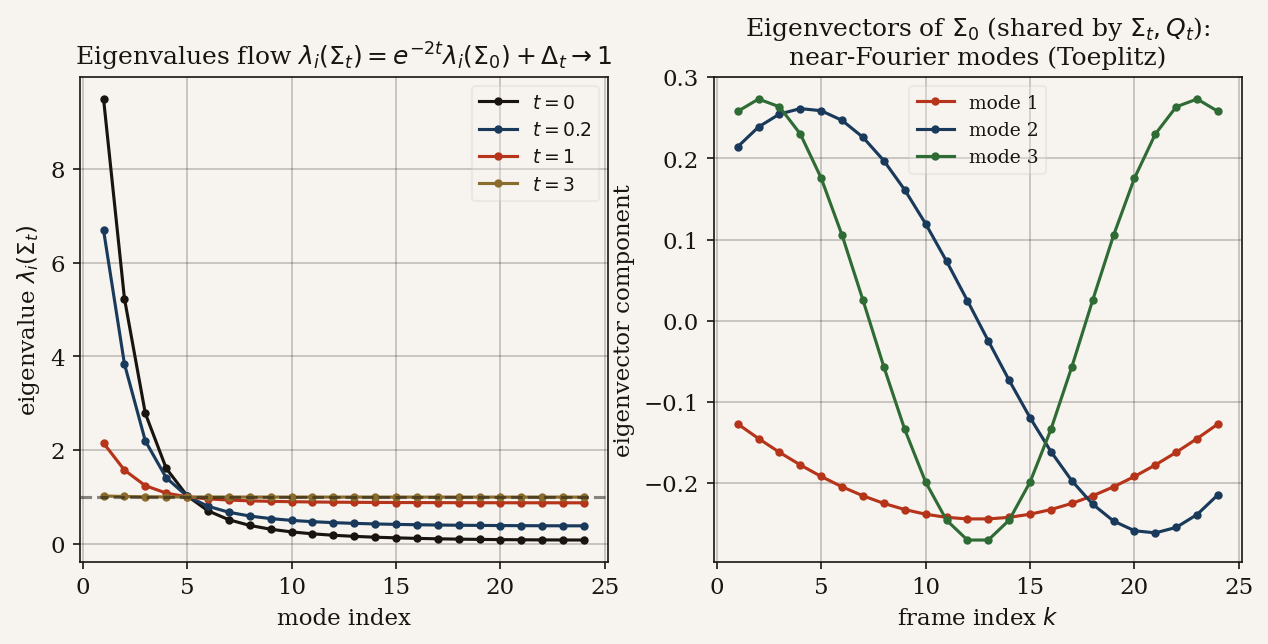

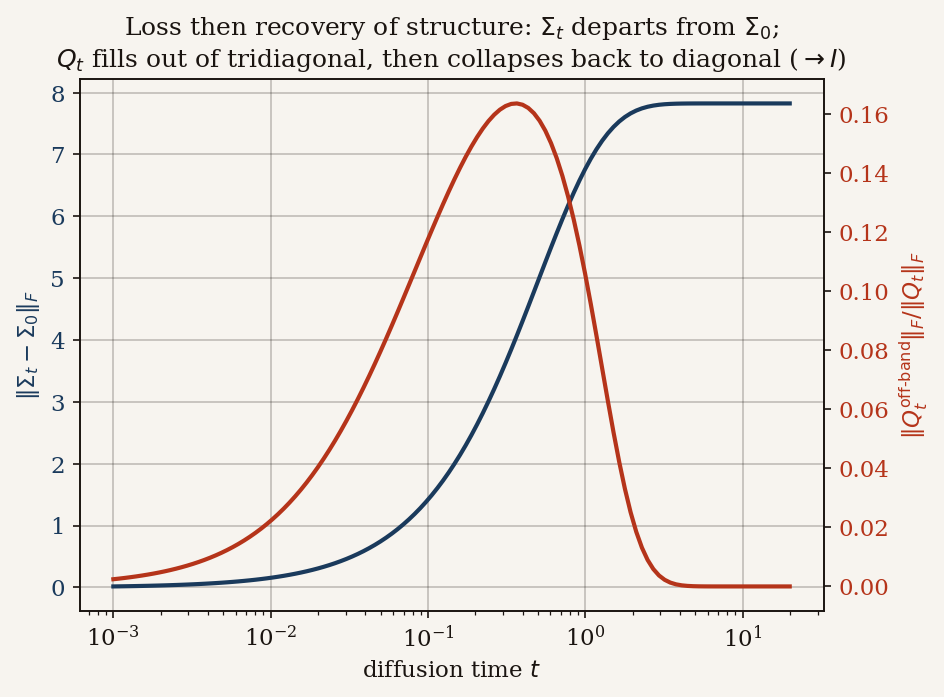

In [8]:
display(Image(filename='figures/fig_precision_lifecycle.png'))
display(Image(filename='figures/fig_band_fill.png'))
display(Image(filename='figures/fig_spectral.png'))
display(Image(filename='figures/fig_tridiag_loss.png'))

## 8. Numerical audit

Every closed-form identity quoted in the paper is checked independently here.

In [9]:
import numerical_audit
numerical_audit.run_all();


Gaussian BP / diffusion-score numerical audit  --  59 checks
[PASS] clean precision Q_0 (K=5, a=+0.30)                           err=2.22e-16  tol=1e-12
[PASS] Q_0 strictly tridiagonal (K=5, a=+0.30)                      err=0.00e+00  tol=0e+00
[PASS] clean precision Q_0 (K=5, a=+0.70)                           err=4.44e-16  tol=1e-12
[PASS] Q_0 strictly tridiagonal (K=5, a=+0.70)                      err=0.00e+00  tol=0e+00
[PASS] clean precision Q_0 (K=5, a=+0.90)                           err=7.99e-15  tol=1e-12
[PASS] Q_0 strictly tridiagonal (K=5, a=+0.90)                      err=0.00e+00  tol=0e+00
[PASS] clean precision Q_0 (K=5, a=-0.50)                           err=1.23e-17  tol=1e-12
[PASS] Q_0 strictly tridiagonal (K=5, a=-0.50)                      err=0.00e+00  tol=0e+00
[PASS] clean precision Q_0 (K=9, a=+0.30)                           err=2.22e-16  tol=1e-12
[PASS] Q_0 strictly tridiagonal (K=9, a=+0.30)                      err=0.00e+00  tol=0e+00
[PASS] clean preci